In [426]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings('ignore')


In [427]:
# Charger le dataset
Dataset = pd.read_csv("zara_data.csv", sep=',', decimal=',')
Dataset.head()
Dataset.info()
Dataset.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   nom         333 non-null    str  
 1   url         333 non-null    str  
 2   couleur     319 non-null    str  
 3   matiere     319 non-null    str  
 4   prix        333 non-null    str  
 5   collection  333 non-null    str  
 6   categorie   333 non-null    str  
dtypes: str(7)
memory usage: 18.3 KB


nom            0
url            0
couleur       14
matiere       14
prix           0
collection     0
categorie      0
dtype: int64

In [428]:
# Mettre tout le texte du dataframe en minuscules
cols_obj = Dataset.select_dtypes(include="object").columns

Dataset[cols_obj] = Dataset[cols_obj].apply(
    lambda col: col.str.lower().str.strip()
)

In [429]:
# Supprimer les lignes contenant des valeurs manquantes
print(Dataset[Dataset.isnull().any(axis=1)])

                                                   nom  \
2                                                  png   
21                                                 png   
57         online exclusive - zara hair cire coiffante   
73   online exclusive - zara hair gel fixation extr...   
78                                                 png   
97          online exclusive - zara hair cire en stick   
106                                                png   
109  online exclusive - poudre texturisante matifia...   
113                                                png   
128                                                png   
185                                                png   
233                                                png   
271                                                png   
296                                                png   

                                                   url couleur matiere  \
2    https://www.zara.com/fr/fr/pull-asymetrique-en... 

In [430]:
# Supprimer les lignes contenant des valeurs manquantes
Dataset= Dataset.dropna()
Dataset = Dataset.reset_index(drop=True)
print(Dataset.isnull().sum())

nom           0
url           0
couleur       0
matiere       0
prix          0
collection    0
categorie     0
dtype: int64


In [431]:
# Convertir les colonnes "likes", "prix" et "prix_total" en numérique, en remplaçant les valeurs non convertibles par NaN
Dataset["prix"] = (
    Dataset["prix"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
)

Dataset["prix"] = pd.to_numeric(Dataset["prix"], errors="coerce")

In [432]:
Dataset["couleur"] = Dataset["couleur"].str.replace("|", "", regex=False).str.strip()

In [433]:
# Fonction de nettoyage pour les couleurs
def nettoyer_texte(x):
    if pd.isna(x):
        return ""
    x = str(x).lower().strip()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))
    return x
# Appliquer la fonction de nettoyage à la colonne "couleur"
def categoriser_couleur(couleur):
    couleur = nettoyer_texte(couleur)

    if couleur == "":
        return "autres"

    # si plusieurs couleurs : on prend la première
    couleur = couleur.split(",")[0].strip()

    if any(mot in couleur for mot in ["noir", "gris", "anthracite", "argente", "argent"]):
        return "noir/gris"

    elif any(mot in couleur for mot in ["blanc", "beige", "ecru", "ivoire", "creme"]):
        return "blanc/beige"

    elif any(mot in couleur for mot in ["marron", "camel", "taupe", "chocolat"]):
        return "marron"

    elif any(mot in couleur for mot in ["bleu", "marine", "turquoise", "denim", "jean"]):
        return "bleu"

    elif any(mot in couleur for mot in ["vert", "kaki", "olive","menthe", "sauge"]):
        return "vert"

    elif any(mot in couleur for mot in ["rouge", "bordeaux", "corail"]):
        return "rouge"

    elif any(mot in couleur for mot in ["rose", "violet", "lilas", "fuchsia", "mauve"]):
        return "rose/violet"

    elif any(mot in couleur for mot in ["jaune", "orange", "ocre", "moutarde", "dore","abricot"]):
        return "jaune/orange"

    elif any(mot in couleur for mot in ["multicolore", "imprime", "fleuri", "raye", "leopard", "zebre", "python"]):
        return "motif/multicolore"

    else:
        return "autres"

Dataset["couleur_generique"] = Dataset["couleur"].apply(categoriser_couleur)

In [434]:
# Nettoyage de la colonne "matiere"
Dataset[["pourcentage", "matiere_principale"]] = (
    Dataset["matiere"]
    .str.extract(r"(\d+)%\s*(.*)")
)
Dataset["pourcentage"] = pd.to_numeric(Dataset["pourcentage"], errors="coerce")
Dataset["matiere_principale"] = (
    Dataset["matiere_principale"]
    .str.split(",")
    .str[0]
    .str.strip()
)
Dataset = Dataset.drop(columns=["matiere"])

In [435]:
mapping = {
    # fibres naturelles végétales
    "coton": "fibre naturelle végétale",
    "lin": "fibre naturelle végétale",

    # fibres naturelles animales
    "laine": "fibre naturelle animale",
    "soie (de mûrier)": "fibre naturelle animale",

    # fibres artificielles
    "viscose": "fibre artificielle",
    "lyocell": "fibre artificielle",
    "modal": "fibre artificielle",
    "acétate": "fibre artificielle",
    "diacétate de cellulose": "fibre artificielle",
    "pâte de cellulose": "fibre artificielle",

    # fibres synthétiques
    "polyester": "fibre synthétique",
    "polyamide": "fibre synthétique",
    "acrylique": "fibre synthétique",
    "polyuréthane": "fibre synthétique",
    "polyéthylène": "fibre synthétique",
    "élastomultiester": "fibre synthétique",
    "acétate de vinyle d éthylène": "fibre synthétique",

    # cuir
    "cuir de vache": "cuir",
    "cuir de chèvre": "cuir",
    "cuir de vachette": "cuir",
    "cuir de porc": "cuir",
    "cuir de mouton": "cuir",

    # autres
    "bois de manguier": "autres",
    "papier": "autres",
    "acier inoxydable": "autres",
    "pierre": "autres",
    "verre": "autres",
    "caoutchouc": "autres",
    "fer": "autres",
    "PCTG": "autres",
    "plastique-acrylique": "autres",
    "plastique": "autres",
    "cuivre": "autres",
}
Dataset["type_matiere_principal"] = (
    Dataset["matiere_principale"]
    .str.strip()
    .str.lower()
    .map(mapping)
    .fillna("autres")
)

In [436]:
Dataset.drop(columns=["url"], inplace=True)

In [437]:
Dataset.drop(columns=["pourcentage"], inplace=True)

In [438]:
# Enregistrer le dataset nettoyé dans un nouveau fichier CSV
Dataset.to_csv("zara_data_clean.csv", index=False)
zara_data_clean.rename(columns={
    "couleur_generique": "couleur",
    "type_matiere_principale": "matiere"
}, inplace=True)
zara_data_clean = pd.read_csv("zara_data_clean.csv", sep=',')

In [439]:
zara_data_clean.head()

,nom,couleur,prix,collection,categorie,couleur_generique,matiere_principale,type_matiere_principal
0,robe mi-longue fluide,mauve poudré,NaN,femme,robe,rose/violet,viscose,fibre artificielle
1,sandales à brides et décor métallique,marron,NaN,femme,sandales,marron,polyuréthane,fibre synthétique
2,combi-short lyocell,noir,NaN,femme,combi-short,noir/gris,lyocell,fibre artificielle
3,jean trf loose folded taille basse à rayures,unique,NaN,femme,jean,autres,coton,fibre naturelle végétale
4,robe fluide à encolure américaine,vert huile,NaN,femme,robe,vert,viscose,fibre artificielle


In [440]:
# Afficher les statistiques descriptives, la forme du dataset et le nombre de valeurs manquantes
print(zara_data_clean.describe())
print(zara_data_clean.shape)
print(zara_data_clean.isnull().sum())

       prix
count   0.0
mean    NaN
std     NaN
min     NaN
25%     NaN
50%     NaN
75%     NaN
max     NaN
(319, 8)
nom                         0
couleur                     0
prix                      319
collection                  0
categorie                   0
couleur_generique           0
matiere_principale          0
type_matiere_principal      0
dtype: int64


In [441]:
zara_data_clean.describe()

,prix
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


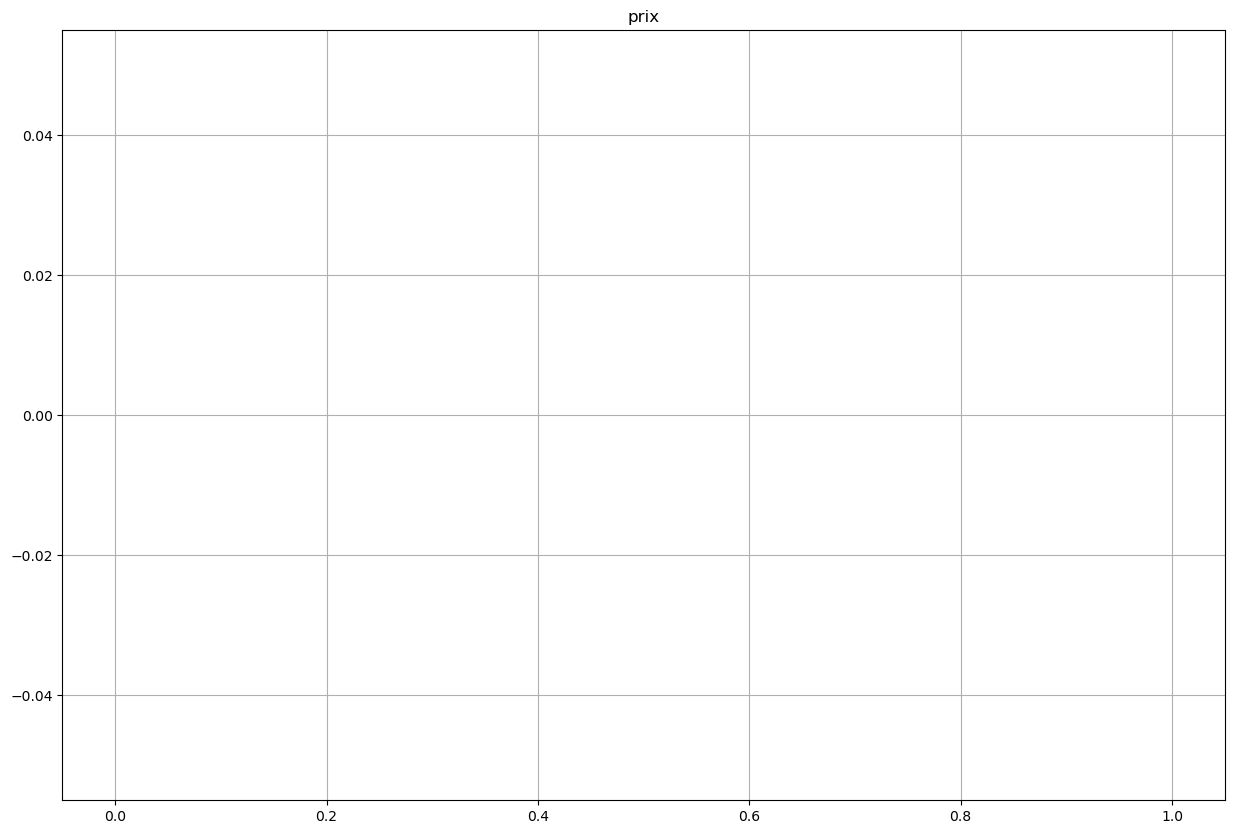

In [442]:
zara_data_clean.hist(figsize=(15,10))
plt.show()

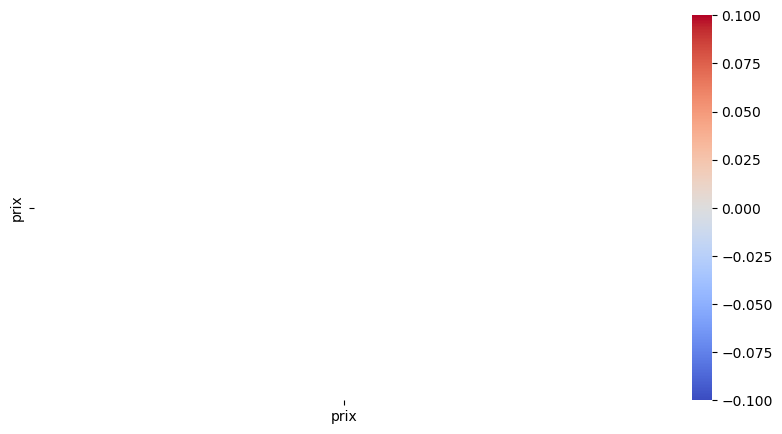

In [443]:
zara_data_clean = zara_data_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,5))
sns.heatmap(zara_data_clean.corr(), annot=True, cmap='coolwarm')
plt.show()

UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

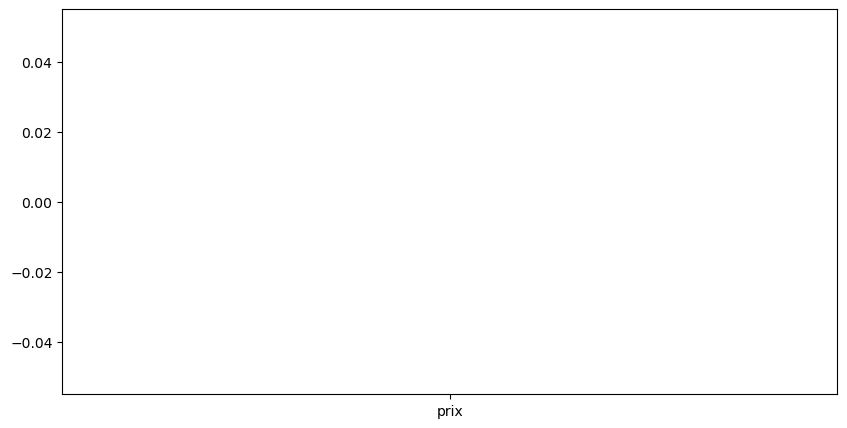

In [444]:
plt.figure(figsize=(10,5))
sns.boxplot(data=zara_data_clean.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()